In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [6]:
df_clean = pd.read_csv("../../../data/steam_indie_preprocessed.csv", engine='python')

In [7]:
df_clean.T

,0,1,2,3,4,5,6,7,8,9,...,61256,61257,61258,61259,61260,61261,61262,61263,61264,61265
appid,1623730,304930,105600,431960,291550,4000,252490,346110,413150,242760,...,988640,1424350,1785940,3591890,3451960,2656520,2145300,2571600,1589920,1513670
spy_name,Palworld,Unturned,Terraria,Wallpaper Engine,Brawlhalla,Garry's Mod,Rust,ARK: Survival Evolved,Stardew Valley,The Forest,...,Christmas Wonderland,Bunny Hill,COVEN,CombatBox,101 Cats in New Delhi,Mycelium Heaven,The Game Store,Meurtre Au Florian,Long Ago: A Puzzle Tale,Fono
owners,50000000 .. 100000000,50000000 .. 100000000,20000000 .. 50000000,20000000 .. 50000000,20000000 .. 50000000,20000000 .. 50000000,20000000 .. 50000000,20000000 .. 50000000,20000000 .. 50000000,20000000 .. 50000000,...,0 .. 20000,0 .. 20000,0 .. 20000,0 .. 20000,0 .. 20000,0 .. 20000,0 .. 20000,0 .. 20000,0 .. 20000,0 .. 20000
positive,358266,506516,1373979,876898,314809,1122546,1071135,612177,872384,599805,...,2,136,156,1,0,33,6,7,15,17
negative,22443,48852,35494,17560,71647,37161,156649,117993,13811,27986,...,0,8,8,0,0,3,4,2,2,0
price_spy,2999,0,999,499,0,999,3999,989,1499,1999,...,349,399,1499,99,99,999,799,499,99,599
ccu,18028,10408,24580,91184,14169,18400,143870,22170,50662,2892,...,0,0,2,0,0,0,0,0,0,0
name_store,Palworld,Unturned,Terraria,Wallpaper Engine,Brawlhalla,Garry's Mod,Rust,ARK: Survival Evolved,Stardew Valley,The Forest,...,Christmas Wonderland,Bunny Hill,COVEN,CombatBox,101 Cats in New Delhi,Mycelium Heaven,The Game Store,Meurtre Au Florian,Long Ago: A Puzzle Tale,Fono
type,game,game,game,game,game,game,game,game,game,game,...,game,game,game,game,game,game,game,game,game,game
genres,"['Action', 'Adventure', 'Indie', 'RPG', 'Early...","['Action', 'Adventure', 'Casual', 'Indie', 'Fr...","['Action', 'Adventure', 'Indie', 'RPG']","['Casual', 'Indie', 'Animation & Modeling', 'D...","['Action', 'Indie', 'Free To Play']","['Casual', 'Indie', 'Simulation']","['Action', 'Adventure', 'Indie', 'Massively Mu...","['Action', 'Adventure', 'Indie', 'Massively Mu...","['Indie', 'RPG', 'Simulation']","['Action', 'Adventure', 'Indie', 'Simulation']",...,"['Adventure', 'Indie']","['Action', 'Casual', 'Indie', 'Racing', 'Sports']","['Action', 'Adventure', 'Indie', 'Early Access']","['Action', 'Indie', 'Simulation', 'Strategy']","['Casual', 'Indie']","['Casual', 'Indie']","['Indie', 'Simulation']","['Adventure', 'Indie']","['Casual', 'Indie']","['Casual', 'Indie']"


In [8]:
print(df_clean[[
    "price_usd",
    "review_total",
    "positive_ratio",
    "owners_mid",
    "days_since_release"
]].describe())

          price_usd  review_total  positive_ratio    owners_mid  \
count  61266.000000  6.126600e+04    60897.000000  6.126600e+04   
mean       6.560010  9.424468e+02        0.760991  7.515278e+04   
std       11.142416  1.509816e+04        0.235797  7.309981e+05   
min        0.000000  0.000000e+00        0.000000  1.000000e+04   
25%        1.090000  6.000000e+00        0.652605  1.000000e+04   
50%        4.990000  2.300000e+01        0.820513  1.000000e+04   
75%        9.990000  1.040000e+02        0.946150  3.500000e+04   
max      999.980000  1.409473e+06        1.000000  7.500000e+07   

       days_since_release  
count        61109.000000  
mean          1924.746093  
std           1119.609589  
min          -1296.000000  
25%            944.000000  
50%           1829.000000  
75%           2769.000000  
max          10522.000000  


In [9]:
#가격별 리뷰수
print(
    df_clean.groupby("price_band", observed=False)["review_total"]
    .mean()
    .sort_values(ascending=False)
)

price_band
30~60    14142.108014
20~30     5415.794047
10~20     2176.538604
Free      1078.451786
5~10       898.460475
0~5        274.736028
60+        119.140496
Name: review_total, dtype: float64


In [10]:
#장르별 리뷰량
genre_cols = [
    "genre_action", "genre_adventure", "genre_rpg",
    "genre_strategy", "genre_simulation", "genre_casual"
]

for col in genre_cols:
    print(f"\n[{col}]")
    print(df_clean.groupby(col)["review_total"].mean())


[genre_action]
genre_action
0     748.241356
1    1170.927457
Name: review_total, dtype: float64

[genre_adventure]
genre_adventure
0     853.500578
1    1057.964768
Name: review_total, dtype: float64

[genre_rpg]
genre_rpg
0     808.606587
1    1514.213235
Name: review_total, dtype: float64

[genre_strategy]
genre_strategy
0    947.113287
1    924.250700
Name: review_total, dtype: float64

[genre_simulation]
genre_simulation
0     792.466579
1    1520.918186
Name: review_total, dtype: float64

[genre_casual]
genre_casual
0    1253.809690
1     550.600398
Name: review_total, dtype: float64


In [11]:
print(df_clean.shape)
print('-'*50)
print(df_clean.columns.tolist())
print('-'*50)
print(df_clean.head())
print('-'*50)
print(df_clean.info())

(61266, 38)
--------------------------------------------------
['appid', 'spy_name', 'owners', 'positive', 'negative', 'price_spy', 'ccu', 'name_store', 'type', 'genres', 'release_date', 'developers', 'owners_low', 'owners_high', 'owners_mid', 'price_usd', 'review_total', 'positive_ratio', 'negative_ratio', 'log_review_total', 'genres_list', 'genre_action', 'genre_adventure', 'genre_rpg', 'genre_strategy', 'genre_simulation', 'genre_casual', 'genre_free_to_play', 'genre_early_access', 'genre_indie', 'release_date_parsed', 'days_since_release', 'release_year', 'release_month', 'is_free', 'price_band', 'review_band', 'game_name']
--------------------------------------------------
     appid          spy_name                 owners  positive  negative  \
0  1623730          Palworld  50000000 .. 100000000    358266     22443   
1   304930          Unturned  50000000 .. 100000000    506516     48852   
2   105600          Terraria   20000000 .. 50000000   1373979     35494   
3   431960  W

In [12]:
na_summary = df_clean.isna().sum().sort_values(ascending=False)
print(na_summary.head(20))

positive_ratio         369
negative_ratio         369
release_month          157
release_year           157
days_since_release     157
release_date_parsed    157
developers              97
release_date            33
spy_name                 8
name_store               4
game_name                3
appid                    0
positive                 0
owners                   0
price_spy                0
negative                 0
price_usd                0
owners_low               0
owners_high              0
type                     0
dtype: int64


In [13]:
df_clean.sort_values(by='review_total', ascending=False).head()

,appid,spy_name,owners,positive,negative,price_spy,ccu,name_store,type,genres,...,genre_early_access,genre_indie,release_date_parsed,days_since_release,release_year,release_month,is_free,price_band,review_band,game_name
2,105600,Terraria,20000000 .. 50000000,1373979,35494,999,24580,Terraria,game,"['Action', 'Adventure', 'Indie', 'RPG']",...,0,1,2011-05-16,5454.0,2011.0,5.0,0,5~10,10000+,Terraria
6,252490,Rust,20000000 .. 50000000,1071135,156649,3999,143870,Rust,game,"['Action', 'Adventure', 'Indie', 'Massively Mu...",...,0,1,2018-02-08,2994.0,2018.0,2.0,0,30~60,10000+,Rust
5,4000,Garry's Mod,20000000 .. 50000000,1122546,37161,999,18400,Garry's Mod,game,"['Casual', 'Indie', 'Simulation']",...,0,1,2006-11-29,7083.0,2006.0,11.0,0,5~10,10000+,Garry's Mod
3,431960,Wallpaper Engine,20000000 .. 50000000,876898,17560,499,91184,Wallpaper Engine,game,"['Casual', 'Indie', 'Animation & Modeling', 'D...",...,0,1,2018-11-16,2713.0,2018.0,11.0,0,0~5,10000+,Wallpaper Engine
8,413150,Stardew Valley,20000000 .. 50000000,872384,13811,1499,50662,Stardew Valley,game,"['Indie', 'RPG', 'Simulation']",...,0,1,NaN,NaN,NaN,NaN,0,10~20,10000+,Stardew Valley


In [14]:
df_clean[df_clean['review_total'] > 30].sort_values(by='review_total', ascending=True).head()


,appid,spy_name,owners,positive,negative,price_spy,ccu,name_store,type,genres,...,genre_early_access,genre_indie,release_date_parsed,days_since_release,release_year,release_month,is_free,price_band,review_band,game_name
16821,1504310,Azure Sky,20000 .. 50000,19,12,399,0,Azure Sky,game,"['Action', 'Adventure', 'Casual', 'Indie', 'RPG']",...,0,1,2021-01-25,1912.0,2021.0,1.0,0,0~5,11~50,Azure Sky
16810,650880,Beyond the Invisible: Evening,20000 .. 50000,18,13,199,0,Beyond the Invisible: Evening,game,"['Adventure', 'Casual', 'Indie']",...,0,1,2017-06-22,3225.0,2017.0,6.0,0,0~5,11~50,Beyond the Invisible: Evening
20017,1412070,Siege the Day,0 .. 20000,16,15,1299,0,Siege the Day,game,"['Action', 'Indie', 'Strategy']",...,0,1,2023-12-21,852.0,2023.0,12.0,0,10~20,11~50,Siege the Day
31735,2895110,Dungeon Deck,0 .. 20000,31,0,999,2,Dungeon Deck,game,"['Adventure', 'Casual', 'Indie', 'RPG', 'Strat...",...,0,1,2024-11-28,509.0,2024.0,11.0,0,5~10,11~50,Dungeon Deck
31830,765590,Co-op SNEK Online,0 .. 20000,27,4,299,0,Co-op SNEK Online,game,"['Action', 'Casual', 'Indie']",...,0,1,2018-04-13,2930.0,2018.0,4.0,0,0~5,11~50,Co-op SNEK Online


In [15]:
df_clean['genres_list']

0        ['Action', 'Adventure', 'Indie', 'RPG', 'Early...
1        ['Action', 'Adventure', 'Casual', 'Indie', 'Fr...
2                  ['Action', 'Adventure', 'Indie', 'RPG']
3        ['Casual', 'Indie', 'Animation & Modeling', 'D...
4                      ['Action', 'Indie', 'Free To Play']
                               ...                        
61261                                  ['Casual', 'Indie']
61262                              ['Indie', 'Simulation']
61263                               ['Adventure', 'Indie']
61264                                  ['Casual', 'Indie']
61265                                  ['Casual', 'Indie']
Name: genres_list, Length: 61266, dtype: str

In [16]:
import ast

df_clean["genres_list"] = df_clean["genres_list"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [17]:
df_2024_after = df_clean[df_clean["release_date_parsed"] >= "2024-01-01"].copy()
df_2024_after = df_2024_after[df_2024_after['review_total'] >= 30]
print("-"*50)
print(df_2024_after.shape)
print("-"*50)
print(df_2024_after.head())
print("-"*50)
print(df_2024_after.tail())

--------------------------------------------------
(4359, 38)
--------------------------------------------------
      appid       spy_name                 owners  positive  negative  \
0   1623730       Palworld  50000000 .. 100000000    358266     22443   
10   899770     Last Epoch   20000000 .. 50000000     88027     22596   
20  3164500     Schedule I   10000000 .. 20000000    200803      3238   
23   251570  7 Days to Die   10000000 .. 20000000    327889     42157   
24  1116170      CyberCorp   10000000 .. 20000000       266        56   

    price_spy    ccu     name_store  type  \
0        2999  18028       Palworld  game   
10       3499   5831     Last Epoch  game   
20       1999  22757     Schedule I  game   
23       4499  17045  7 Days to Die  game   
24       1499      3      CyberCorp  game   

                                               genres  ... genre_early_access  \
0   ['Action', 'Adventure', 'Indie', 'RPG', 'Early...  ...                  1   
10            [

In [18]:
all_genres = df_2024_after["genres_list"].explode().dropna()

print(all_genres.unique())
print("장르 개수:", len(all_genres.unique()))

<StringArray>
[               'Action',             'Adventure',                 'Indie',
                   'RPG',          'Early Access',            'Simulation',
              'Strategy', 'Massively Multiplayer',                'Casual',
          'Free To Play',                'Racing',                'Sports',
            'Accounting',      'Game Development', 'Design & Illustration',
             'Education',     'Software Training',             'Utilities',
  'Animation & Modeling',         'Photo Editing']
Length: 20, dtype: str
장르 개수: 20


In [19]:
genre_counts = all_genres.value_counts()

genre_counts

genres_list
Indie                    4359
Adventure                2138
Action                   1816
Casual                   1714
Simulation               1358
RPG                      1212
Strategy                 1002
Early Access              464
Free To Play              206
Sports                    145
Racing                    122
Massively Multiplayer     106
Utilities                   7
Design & Illustration       5
Game Development            3
Software Training           3
Animation & Modeling        3
Education                   2
Accounting                  1
Photo Editing               1
Name: count, dtype: int64

윌슨스 스코어적용


In [20]:
import numpy as np

def wilson_score(pos, neg, z=1.96):
    n = pos + neg
    if n == 0:
        return np.nan
    
    p = pos / n
    
    score = (
        p + (z**2)/(2*n)
        - z * np.sqrt((p*(1-p) + (z**2)/(4*n)) / n)
    ) / (1 + (z**2)/n)
    
    return score

In [21]:
df_2024_after["wilson_score"] = df_2024_after.apply(
    lambda row: wilson_score(row["positive"], row["negative"]),
    axis=1
)

In [22]:
df_2024_after["review_group"] = pd.cut(
    df_2024_after["review_total"],
    bins=[0, 100, 500, 999999999],
    labels=["소형(30~100)", "중형(101~500)", "대형(501+)"]
)

In [23]:
def get_top_bottom(df, group_name, n=5):
    group_df = df_2024_after[df_2024_after["review_group"] == group_name]
    
    top = group_df.sort_values("wilson_score", ascending=False).head(n)
    bottom = group_df.sort_values("wilson_score", ascending=True).head(n)
    
    return top, bottom

In [24]:
from IPython.display import display

In [25]:
groups = ["소형(30~100)", "중형(101~500)", "대형(501+)"]

for g in groups:
    print(f"\n===== {g} =====")
    
    top, bottom = get_top_bottom(df_clean, g)
    
    print("\n[상위 5]")
    display(top[["game_name", "review_total", "positive_ratio", "wilson_score"]])
    
    print("\n[하위 5]")
    display(bottom[["game_name", "review_total", "positive_ratio", "wilson_score"]])


===== 소형(30~100) =====

[상위 5]


,game_name,review_total,positive_ratio,wilson_score
59595,Six-Ear Macaque: Awakening,98,1.0,0.962279
9081,This Magical Girl is a B☆tch,96,1.0,0.961523
37193,Cape Hideous,94,1.0,0.960737
20750,WYRMHALL: Brush and Banter,87,1.0,0.957711
46116,Projected Dreams,86,1.0,0.957240



[하위 5]


,game_name,review_total,positive_ratio,wilson_score
29773,THE WALLWAY,37,0.108108,0.042851
42678,Crab Game 2,35,0.228571,0.120657
53949,My Museum: Treasure Hunter,35,0.228571,0.120657
35212,School Owner,62,0.225806,0.139551
27773,Sad Satan,34,0.294118,0.168345



===== 중형(101~500) =====

[상위 5]


...

,game_name,review_total,positive_ratio,wilson_score
33969,我亲爱的妹妹 Happy Sisters Life,117,0.128205,0.079256
26017,Age of Survival,242,0.119835,0.084745
37421,Bodycam Real Shoot,193,0.331606,0.269041
10449,Don't Shout Together,452,0.331858,0.290025
26492,エスカレーター | Escalator,121,0.380165,0.298620



===== 대형(501+) =====

[상위 5]


,game_name,review_total,positive_ratio,wilson_score
10722,Kabuto Park,1036,0.999035,0.994553
1656,The WereCleaner,10119,0.994367,0.992709
9669,Beastieball,1168,0.995719,0.990018
5790,Monster Prom 4: Monster Con,1444,0.993075,0.987299
3760,Buy a Croquette!,4397,0.990448,0.987114



[하위 5]


,game_name,review_total,positive_ratio,wilson_score
6041,EGG RAIDERS,947,0.173178,0.150410
1130,THE 4 SINS,3942,0.243278,0.230137
798,Feed the Cups,13208,0.296941,0.289209
2240,Unplagued,4797,0.326037,0.312915
1087,Cultivation Tales,13639,0.375834,0.367741


장르별로 나누기

In [26]:
#1. 먼저 genres_list가 진짜 리스트인지 확인
import ast

df_2024_after["genres_list"] = df_2024_after["genres_list"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [27]:
#explode 해서 장르별 분석용 데이터 만들기
df_genre = df_2024_after.explode("genres_list").copy()
df_genre = df_genre.rename(columns={"genres_list": "genre"})

In [28]:
#장르 종류 확인
genre_list = sorted(df_genre["genre"].dropna().unique())
print(genre_list)
print("장르 개수:", len(genre_list))

['Accounting', 'Action', 'Adventure', 'Animation & Modeling', 'Casual', 'Design & Illustration', 'Early Access', 'Education', 'Free To Play', 'Game Development', 'Indie', 'Massively Multiplayer', 'Photo Editing', 'RPG', 'Racing', 'Simulation', 'Software Training', 'Sports', 'Strategy', 'Utilities']
장르 개수: 20


In [29]:
#장르별 상위/하위 뽑는 함수
def get_top_bottom_by_genre(df, genre_name, n=5):
    genre_df = df[df["genre"] == genre_name].copy()

    top = genre_df.sort_values("wilson_score", ascending=False).head(n).copy()
    bottom = genre_df.sort_values("wilson_score", ascending=True).head(n).copy()

    return top, bottom

In [30]:
# 특정 장르 하나만 보기
from IPython.display import display

def pretty_show_table(df, title, cmap="Blues"):
    df_show = df.copy()

    df_show["game_name"] = df_show["game_name"].astype(str).str.slice(0, 35)
    df_show["positive_ratio"] = (df_show["positive_ratio"] * 100).round(2)
    df_show["wilson_score"] = df_show["wilson_score"].round(4)

    df_show = df_show.rename(columns={
        "game_name": "게임명",
        "review_total": "리뷰 수",
        "positive_ratio": "긍정률(%)",
        "wilson_score": "Wilson Score",
        "genre": "장르"
    })

    print(title)
    display(
        df_show.style
        .hide(axis="index")
        .background_gradient(subset=["Wilson Score"], cmap=cmap)
        .set_properties(**{
            "text-align": "left",
            "padding": "6px"
        })
    )

In [31]:
#여러 장르를 반복해서 보기
target_genres = ["Action", "Adventure", "RPG", "Strategy", "Simulation", "Casual"]

for g in target_genres:
    top, bottom = get_top_bottom_by_genre(df_genre, g, n=5)

    pretty_show_table(
        top[["game_name", "genre", "review_total", "positive_ratio", "wilson_score"]],
        f"{g} 장르 상위 5",
        cmap="Blues"
    )

    pretty_show_table(
        bottom[["game_name", "genre", "review_total", "positive_ratio", "wilson_score"]],
        f"{g} 장르 하위 5",
        cmap="Reds"
    )

Action 장르 상위 5


AttributeError: The '.style' accessor requires jinja2

In [ ]:
#장르별로 한 장짜리 표로 합치기
def make_genre_rank_table(df, genres, top_n=3, bottom=False):
    result = []

    for g in genres:
        genre_df = df[df["genre"] == g].copy()

        if bottom:
            ranked = genre_df.sort_values("wilson_score", ascending=True).head(top_n).copy()
        else:
            ranked = genre_df.sort_values("wilson_score", ascending=False).head(top_n).copy()

        ranked = ranked.reset_index(drop=True)
        ranked["rank"] = ranked.index + 1
        ranked["genre_name"] = g

        result.append(ranked)

    final_table = pd.concat(result, axis=0, ignore_index=True)

    final_table["positive_rate(%)"] = (final_table["positive_ratio"] * 100).round(2)
    final_table["wilson_score"] = final_table["wilson_score"].round(4)

    final_table = final_table[
        ["rank", "appid", "game_name", "genre_name", "review_total", "positive_rate(%)", "wilson_score"]
    ]

    return final_table

In [ ]:
target_genres = ["Action", "Adventure", "RPG", "Strategy", "Simulation", "Casual"]

genre_top_table = make_genre_rank_table(df_genre, target_genres, top_n=3, bottom=False)
genre_bottom_table = make_genre_rank_table(df_genre, target_genres, top_n=3, bottom=True)

display(genre_top_table)
display(genre_bottom_table)

,rank,appid,game_name,genre_name,review_total,positive_rate(%),wilson_score
0,1,2795000,The WereCleaner,Action,10119,99.44,0.9927
1,2,1405500,Angel at Dusk,Action,1420,99.08,0.9844
2,3,3164500,Schedule I,Action,204041,98.41,0.9836
3,1,1864950,Beastieball,Adventure,1168,99.57,0.9900
4,2,2073910,A Webbing Journey,Adventure,497,99.80,0.9887
5,3,2167960,Buy a Croquette!,Adventure,4397,99.04,0.9871
6,1,3376990,Kabuto Park,RPG,1036,99.90,0.9946
7,2,1864950,Beastieball,RPG,1168,99.57,0.9900
8,3,2167960,Buy a Croquette!,RPG,4397,99.04,0.9871
9,1,3376990,Kabuto Park,Strategy,1036,99.90,0.9946


,rank,appid,game_name,genre_name,review_total,positive_rate(%),wilson_score
0,1,3253990,THE WALLWAY,Action,37,10.81,0.0429
1,2,369080,Age of Survival,Action,242,11.98,0.0847
2,3,3349150,Crab Game 2,Action,35,22.86,0.1207
3,1,369080,Age of Survival,Adventure,242,11.98,0.0847
4,2,1833710,My Museum: Treasure Hunter,Adventure,35,22.86,0.1207
5,3,3253440,EGG RAIDERS,Adventure,947,17.32,0.1504
6,1,3492320,我亲爱的妹妹 Happy Sisters Life,RPG,117,12.82,0.0793
7,2,2866960,Wizlite: Everybody loved RPGs,RPG,33,30.30,0.1738
8,3,1775080,Animal Simulator,RPG,45,33.33,0.2136
9,1,1833710,My Museum: Treasure Hunter,Strategy,35,22.86,0.1207


In [ ]:
def get_top_bottom_by_genre_and_group(df, genre_name, review_group, n=5):
    subset = df[(df["genre"] == genre_name) & (df["review_group"] == review_group)].copy()

    top = subset.sort_values("wilson_score", ascending=False).head(n).copy()
    bottom = subset.sort_values("wilson_score", ascending=True).head(n).copy()

    return top, bottom

In [ ]:
top, bottom = get_top_bottom_by_genre_and_group(df_genre, "Action", "소형(30~100)", n=5)

pretty_show_table(
    top[["game_name", "genre", "review_total", "positive_ratio", "wilson_score"]],
    "Action | 소형(30~100) 상위 5",
    cmap="Blues"
)

pretty_show_table(
    bottom[["game_name", "genre", "review_total", "positive_ratio", "wilson_score"]],
    "Action | 소형(30~100) 하위 5",
    cmap="Reds"
)

Action | 소형(30~100) 상위 5

게임명,장르,리뷰 수,긍정률(%),Wilson Score
Six-Ear Macaque: Awakening,Action,98,100.000000,0.962300
CatboyZOOM,Action,81,100.000000,0.954700
Unless,Action,79,100.000000,0.953600
Bahamut and the Waqwaq Tree,Action,75,100.000000,0.951300
Bubble Ghost Remake,Action,72,100.000000,0.949300


Action | 소형(30~100) 하위 5


게임명,장르,리뷰 수,긍정률(%),Wilson Score
THE WALLWAY,Action,37,10.810000,0.042900
Crab Game 2,Action,35,22.860000,0.120700
Sad Satan,Action,34,29.410000,0.168300
Obscula,Action,37,29.730000,0.174900
Animal Simulator,Action,45,33.330000,0.213600


장르 분석용 데이터 만들기

In [ ]:
df_2024_after["genres_list"] = df_2024_after["genres_list"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [ ]:
df_genre = df_2024_after.explode("genres_list").copy()
df_genre = df_genre.rename(columns={"genres_list": "genre"})

In [ ]:
print(df_genre.head())
print(df_genre.shape)
print(df_genre["genre"].unique())

     appid  spy_name                 owners  positive  negative  price_spy  \
0  1623730  Palworld  50000000 .. 100000000    358266     22443       2999   
0  1623730  Palworld  50000000 .. 100000000    358266     22443       2999   
0  1623730  Palworld  50000000 .. 100000000    358266     22443       2999   
0  1623730  Palworld  50000000 .. 100000000    358266     22443       2999   
0  1623730  Palworld  50000000 .. 100000000    358266     22443       2999   

     ccu name_store  type                                             genres  \
0  18028   Palworld  game  ['Action', 'Adventure', 'Indie', 'RPG', 'Early...   
0  18028   Palworld  game  ['Action', 'Adventure', 'Indie', 'RPG', 'Early...   
0  18028   Palworld  game  ['Action', 'Adventure', 'Indie', 'RPG', 'Early...   
0  18028   Palworld  game  ['Action', 'Adventure', 'Indie', 'RPG', 'Early...   
0  18028   Palworld  game  ['Action', 'Adventure', 'Indie', 'RPG', 'Early...   

   ... release_date_parsed days_since_release  rel

In [ ]:
genre_counts = df_genre["genre"].value_counts()
print(genre_counts)

genre
Indie                    4359
Adventure                2138
Action                   1816
Casual                   1714
Simulation               1358
RPG                      1212
Strategy                 1002
Early Access              464
Free To Play              206
Sports                    145
Racing                    122
Massively Multiplayer     106
Utilities                   7
Design & Illustration       5
Game Development            3
Software Training           3
Animation & Modeling        3
Education                   2
Accounting                  1
Photo Editing               1
Name: count, dtype: int64


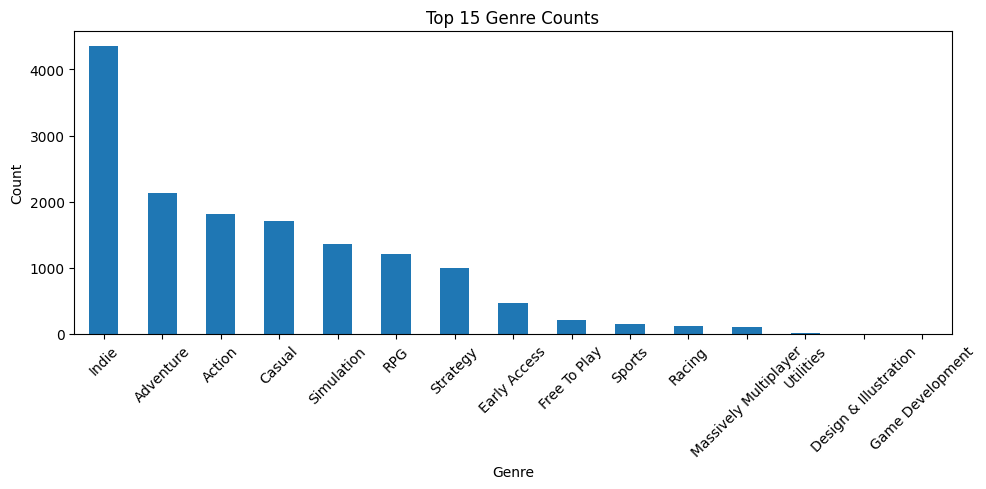

In [ ]:
plt.figure(figsize=(10, 5))
genre_counts.head(15).plot(kind="bar")
plt.title("Top 15 Genre Counts")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

인디 제거 버전

In [ ]:
genre_counts_no_indie = df_genre[df_genre["genre"] != "Indie"]["genre"].value_counts()
print(genre_counts_no_indie.head(15))

genre
Adventure                2138
Action                   1816
Casual                   1714
Simulation               1358
RPG                      1212
Strategy                 1002
Early Access              464
Free To Play              206
Sports                    145
Racing                    122
Massively Multiplayer     106
Utilities                   7
Design & Illustration       5
Game Development            3
Software Training           3
Name: count, dtype: int64


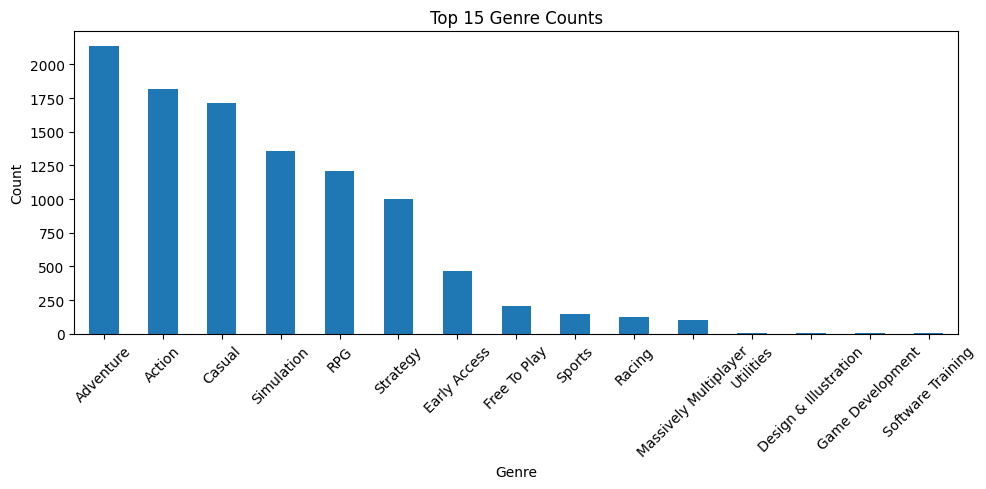

In [ ]:
plt.figure(figsize=(10, 5))
genre_counts_no_indie.head(15).plot(kind="bar")
plt.title("Top 15 Genre Counts")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

장르별 평균 긍정률 보기

In [ ]:
genre_positive_mean = (
    df_genre.groupby("genre")["positive_ratio"]
    .mean()
    .sort_values(ascending=False)
)

print(genre_positive_mean)

genre
Accounting               0.943262
Design & Illustration    0.895380
Software Training        0.892852
Education                0.869399
Sports                   0.861537
Racing                   0.857663
Casual                   0.851314
Photo Editing            0.844444
Indie                    0.843650
Adventure                0.838920
Strategy                 0.833215
Action                   0.829852
RPG                      0.827754
Early Access             0.820071
Simulation               0.819067
Game Development         0.815245
Utilities                0.811887
Free To Play             0.792857
Animation & Modeling     0.778397
Massively Multiplayer    0.728078
Name: positive_ratio, dtype: float64


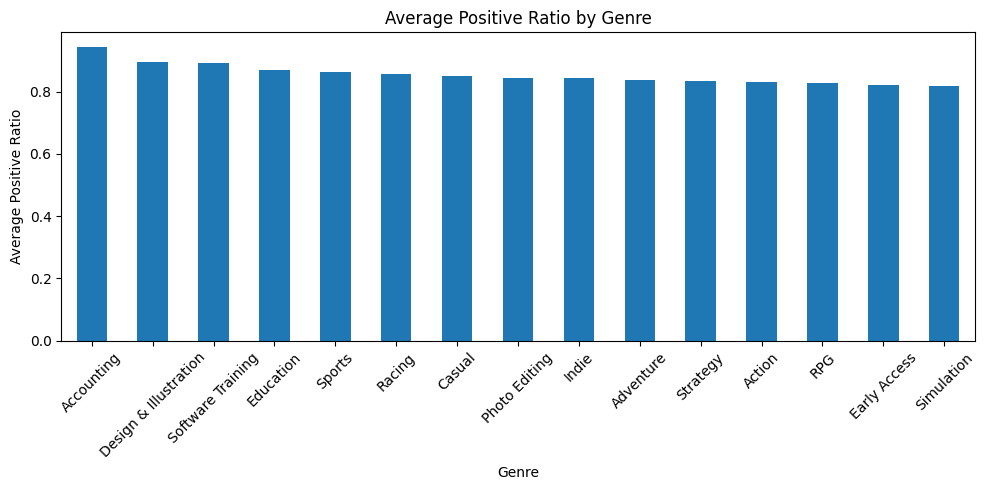

In [ ]:
plt.figure(figsize=(10, 5))
genre_positive_mean.head(15).plot(kind="bar")
plt.title("Average Positive Ratio by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Positive Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

6. 장르별 평균 판매량 추정치 보기

In [ ]:
genre_owners_mean = (
    df_genre.groupby("genre")["owners_mid"]
    .mean()
    .sort_values(ascending=False)
)

print(genre_owners_mean)

genre
Early Access             262467.672414
RPG                      196930.693069
Massively Multiplayer    185047.169811
Action                   174201.541850
Adventure                148306.828812
Strategy                 127125.748503
Simulation               124186.303387
Indie                    108427.391604
Free To Play              92257.281553
Accounting                75000.000000
Casual                    54906.651109
Racing                    53196.721311
Sports                    30689.655172
Game Development          18333.333333
Design & Illustration     15000.000000
Animation & Modeling      10000.000000
Education                 10000.000000
Photo Editing             10000.000000
Software Training         10000.000000
Utilities                 10000.000000
Name: owners_mid, dtype: float64


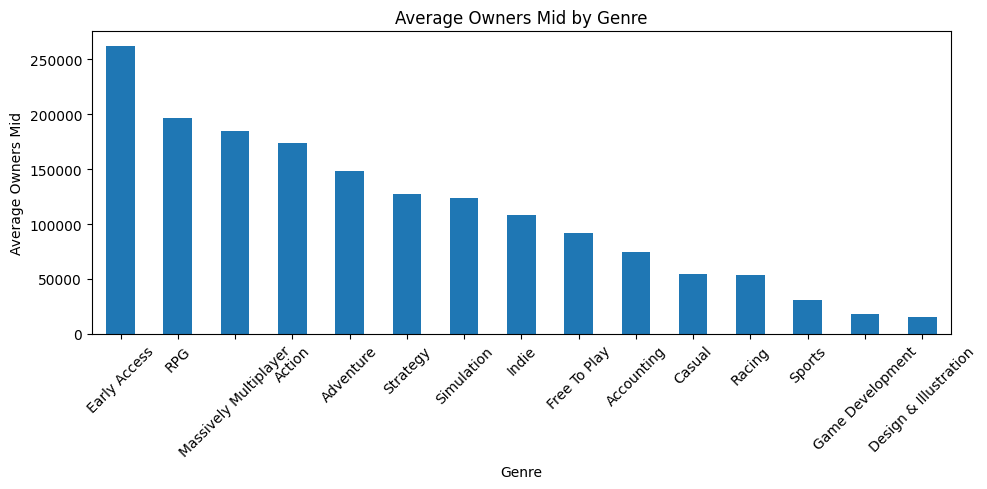

In [ ]:
plt.figure(figsize=(10, 5))
genre_owners_mean.head(15).plot(kind="bar")
plt.title("Average Owners Mid by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Owners Mid")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

장르별 요약표 만들기

In [ ]:
genre_summary = (
    df_genre.groupby("genre")
    .agg(
        game_count=("appid", "count"),
        avg_review_total=("review_total", "mean"),
        median_review_total=("review_total", "median"),
        avg_positive_ratio=("positive_ratio", "mean"),
        avg_wilson_score=("wilson_score", "mean"),
        avg_owners_mid=("owners_mid", "mean")
    )
)

In [ ]:
#반올림
genre_summary["avg_review_total"] = genre_summary["avg_review_total"].round(2)
genre_summary["median_review_total"] = genre_summary["median_review_total"].round(2)
genre_summary["avg_positive_ratio"] = (genre_summary["avg_positive_ratio"] * 100).round(2)
genre_summary["avg_wilson_score"] = genre_summary["avg_wilson_score"].round(4)
genre_summary["avg_owners_mid"] = genre_summary["avg_owners_mid"].round(2)

print(genre_summary.sort_values("avg_wilson_score", ascending=False))

                       game_count  avg_review_total  median_review_total  \
genre                                                                      
Accounting                      1            141.00                141.0   
Software Training               3            173.00                 83.0   
Education                       2            218.00                218.0   
Design & Illustration           5             76.60                 70.0   
Sports                        145            316.21                110.0   
Racing                        122           1557.99                 93.0   
Casual                       1714            858.89                 99.5   
Indie                        4359           1443.07                111.0   
Adventure                    2138           1767.21                117.0   
Strategy                     1002           2015.59                151.0   
RPG                          1212           2020.81                164.5   
Action      

In [ ]:
# 게임 갯수가 30개 이하인것 제거
genre_summary_filtered = genre_summary[genre_summary["game_count"] >= 30].copy()
print(genre_summary_filtered.sort_values("avg_wilson_score", ascending=False))

                       game_count  avg_review_total  median_review_total  \
genre                                                                      
Sports                        145            316.21                110.0   
Racing                        122           1557.99                 93.0   
Casual                       1714            858.89                 99.5   
Indie                        4359           1443.07                111.0   
Adventure                    2138           1767.21                117.0   
Strategy                     1002           2015.59                151.0   
RPG                          1212           2020.81                164.5   
Action                       1816           2065.01                119.0   
Simulation                   1358           2204.95                150.0   
Early Access                  464           2334.19                119.5   
Free To Play                  206           1104.33                115.5   
Massively Mu

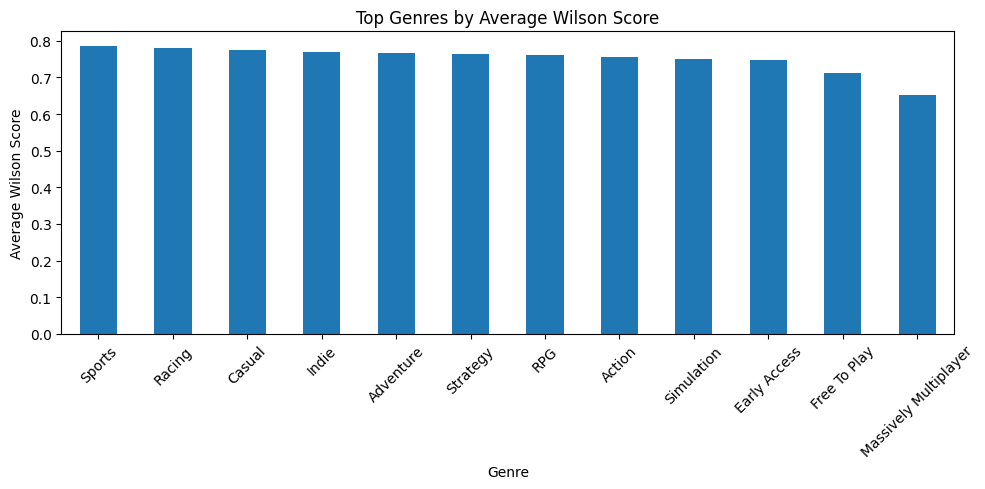

In [ ]:
#silson score 기준
plt.figure(figsize=(10, 5))
genre_summary_filtered.sort_values("avg_wilson_score", ascending=False)["avg_wilson_score"].head(15).plot(kind="bar")
plt.title("Top Genres by Average Wilson Score")
plt.xlabel("Genre")
plt.ylabel("Average Wilson Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

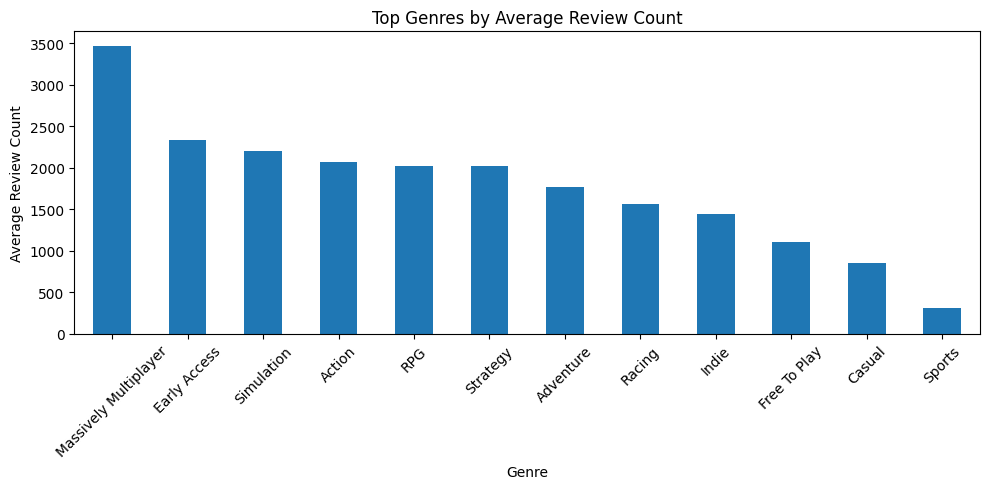

In [ ]:
#리뷰수 기준
plt.figure(figsize=(10, 5))
genre_summary_filtered.sort_values("avg_review_total", ascending=False)["avg_review_total"].head(15).plot(kind="bar")
plt.title("Top Genres by Average Review Count")
plt.xlabel("Genre")
plt.ylabel("Average Review Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#
def get_top_bottom_by_genre(df, genre_name, n=5):
    genre_df = df[df["genre"] == genre_name].copy()
    top = genre_df.sort_values("wilson_score", ascending=False).head(n).copy()
    bottom = genre_df.sort_values("wilson_score", ascending=True).head(n).copy()
    return top, bottom

In [ ]:
top_action, bottom_action = get_top_bottom_by_genre(df_genre, "Massively Multiplayer", n=5)

print("[Action 상위 5]")
print(top_action[["game_name", "review_total", "positive_ratio", "wilson_score", "price_usd"]])

print("\n[Action 하위 5]")
print(bottom_action[["game_name", "review_total", "positive_ratio", "wilson_score", "price_usd"]])

[Action 상위 5]
                                   game_name  review_total  positive_ratio  \
249                               WEBFISHING         65810        0.979684   
59447                            Dusty Derby            69        1.000000   
7619                                    天缘传说           375        0.965333   
8464   攻城与召唤 Siege and Summons 【5分钟一局 策略竞技 】          1074        0.953445   
3023                      LIZARDS MUST DIE 2          1429        0.951015   

       wilson_score  price_usd  
249        0.978578       4.99  
59447      0.947261       9.99  
7619       0.941599       0.00  
8464       0.939148       0.00  
3023       0.938564       9.99  

[Action 하위 5]
                                game_name  review_total  positive_ratio  \
29773                         THE WALLWAY            37        0.108108   
48610              The Dawn: Sniper's Way            31        0.419355   
40854                     Project Speed 2            68        0.382353   
1705